# Step 3 — Topic Modeling (Complaint & Praise Themes)

**Project:** Customer Review Intelligence — NLP-Powered Product & Reputation Analytics

Automatically extracts recurring themes from review text — no manual labeling —
using **NMF (Non-negative Matrix Factorization)** on TF-IDF vectors.

**Why NMF instead of BERTopic?** BERTopic needs a transformer embedding model
downloaded from Hugging Face. NMF on TF-IDF is the standard lightweight
alternative: fast, fully offline, and produces clean, interpretable topics for
short texts like reviews. (If you have full internet access later and want to
try BERTopic, the same input/output shape applies — just swap the modeling step.)

We run **two separate topic models**: one on negative reviews (complaint themes)
and one on positive reviews (praise themes), since that split is what's actually
actionable for a product team.

**Reads:** `data\processed\reviews_with_sentiment.csv`
**Writes:** `data\processed\reviews_with_topics.csv`, `data\processed\topic_summary.csv`


## Setup

In [1]:
# If not already installed:
# !pip install scikit-learn pandas matplotlib

In [2]:
"""
topic_modeling.py
-------------------
Step 3: Topic Modeling using NMF (Non-negative Matrix Factorization) on
TF-IDF vectors. Runs fully offline via scikit-learn — no model downloads.

Why NMF instead of BERTopic?
BERTopic needs a transformer embedding model downloaded from Hugging Face.
NMF on TF-IDF is the standard lightweight alternative: fast, fully local,
and produces clean, interpretable topics for short texts like reviews.
(If you have internet access and want to try BERTopic later, the same
input/output shape applies — just swap the modeling step.)

Approach: separate topic models for NEGATIVE reviews (complaint themes)
and POSITIVE reviews (praise themes), since that's what's actually
actionable for a product team.

Reads:  data/processed/reviews_with_sentiment.csv
Writes: data/processed/reviews_with_topics.csv
        data/processed/topic_summary.csv
"""

from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

BASE_DIR = Path(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

N_TOPICS_NEGATIVE = 10
N_TOPICS_POSITIVE = 8

# ---------------------------------------------------------------------
# Keyword -> human-readable label mapping.
# Topic modeling gives you clusters of words; a person still has to look
# at each cluster and decide what to call it. This function automates
# that step using common review-domain keyword patterns, and falls back
# to showing the raw top words when nothing matches (so it's transparent
# and still works if you swap in totally different review data later).
# Separate rule sets for complaint vs. praise topics, since the same
# word (e.g. "price") means something different in each context.
# ---------------------------------------------------------------------
LABEL_RULES_NEGATIVE = [
    (["smell", "chemical", "odor", "disgusting"], "Product Odor / Chemical Smell"),
    (["loud", "noise", "irritating", "operation"], "Noisy During Operation"),
    (["sizing", "wrong", "small", "size", "runs"], "Sizing Issues"),
    (["instructions", "confusing", "manual", "written", "poorly"], "Confusing Instructions"),
    (["terrible", "figure", "setup", "trying", "included"], "Frustrating Setup Experience"),
    (["customer", "support", "response", "reached", "got"], "Unresponsive Customer Support"),
    (["return", "process", "rude", "painful"], "Difficult Return Process"),
    (["overpriced", "waste", "worth", "way"], "Overpriced / Poor Value"),
    (["quality", "build", "plastic", "snap", "parts"], "Poor Build Quality"),
    (["fell", "apart", "minimal", "disappointed", "frustrated"], "Product Fell Apart / Durability"),
    (["delivery", "package", "arrived", "late", "estimated", "window"], "Late / Delayed Delivery"),
    (["damaged", "dented", "box", "crushed", "scratched"], "Damaged in Shipping"),
    (["dead", "arrival", "battery", "stopped", "malfunctioned", "broken"], "Defective on Arrival"),
    (["okay", "decent", "job", "average", "special"], "Lukewarm / Unremarkable Experience"),
]

LABEL_RULES_POSITIVE = [
    (["seller", "resolved", "issue", "quickly", "professionally", "happy"], "Responsive Customer Service"),
    (["great", "experience", "incredibly", "friendly"], "Great Overall Experience"),
    (["fits", "compact", "stylish", "space", "satisfied"], "Compact / Fits Well"),
    (["beautiful", "design", "sleek", "looks"], "Attractive Design"),
    (["better", "deal", "amazing", "suggests", "performs", "price", "bad", "range"], "Great Value for Money"),
    (["intuitive", "setup", "easy", "needed", "box", "wonderfully"], "Easy Setup / Ease of Use"),
    (["shipping", "excellent", "condition", "pleased", "fast", "arrived"], "Fast, Reliable Shipping"),
    (["works", "perfectly", "described", "issues", "performance"], "Reliable Performance"),
    (["update", "review", "time", "far", "using"], "Positive Early Impressions"),
]


def auto_label(top_words, rules):
    """Scores each candidate label by how many of its keywords appear in
    the topic's top words, returns the best match, or the raw words if
    nothing scores above 0."""
    top_words_set = set(top_words)
    best_label, best_score = None, 0
    for keywords, label in rules:
        score = sum(1 for kw in keywords if any(kw in w for w in top_words_set))
        if score > best_score:
            best_score, best_label = score, label
    if best_label:
        return best_label
    return "Other: " + ", ".join(top_words[:3])


def run_topic_model(texts, n_topics, rules):
    """Fits TF-IDF + NMF on a set of review texts. Returns:
    - doc_topic: array of topic assignment per document
    - topic_labels: dict {topic_id: human-readable label}
    - topic_top_words: dict {topic_id: list of top words}
    """
    vectorizer = TfidfVectorizer(max_df=0.8, min_df=5, stop_words="english", ngram_range=(1, 2))
    X = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    nmf = NMF(n_components=n_topics, random_state=42, max_iter=500)
    W = nmf.fit_transform(X)
    H = nmf.components_

    topic_labels, topic_top_words = {}, {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        topic_top_words[topic_idx] = top_words
        topic_labels[topic_idx] = auto_label(top_words, rules)

    doc_topic = W.argmax(axis=1)
    doc_topic_strength = W.max(axis=1)
    return doc_topic, doc_topic_strength, topic_labels, topic_top_words


# ---------------------------------------------------------------------
# Load sentiment-scored reviews
# ---------------------------------------------------------------------
df = pd.read_csv(PROCESSED_DIR / "reviews_with_sentiment.csv")
print(f"Loaded {len(df)} reviews.")

df["theme"] = None
df["theme_strength"] = 0.0

# ---------------------------------------------------------------------
# Negative reviews -> complaint themes
# ---------------------------------------------------------------------
neg_mask = df["sentiment_label"] == "negative"
neg_texts = df.loc[neg_mask, "review_text"]

neg_topics, neg_strength, neg_labels, neg_words = run_topic_model(
    neg_texts, N_TOPICS_NEGATIVE, LABEL_RULES_NEGATIVE
)
df.loc[neg_mask, "theme"] = [neg_labels[t] for t in neg_topics]
df.loc[neg_mask, "theme_strength"] = neg_strength

# ---------------------------------------------------------------------
# Positive reviews -> praise themes
# ---------------------------------------------------------------------
pos_mask = df["sentiment_label"] == "positive"
pos_texts = df.loc[pos_mask, "review_text"]

pos_topics, pos_strength, pos_labels, pos_words = run_topic_model(
    pos_texts, N_TOPICS_POSITIVE, LABEL_RULES_POSITIVE
)
df.loc[pos_mask, "theme"] = [pos_labels[t] for t in pos_topics]
df.loc[pos_mask, "theme_strength"] = pos_strength

# neutral reviews get no specific theme (not enough signal / not actionable)
df.loc[df["sentiment_label"] == "neutral", "theme"] = "General / Mixed Feedback"

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
out_path = PROCESSED_DIR / "reviews_with_topics.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

# Topic summary table (for the dashboard later).
# Multiple NMF topics can land on the same human-readable label (e.g. two
# slightly different "confusing setup" clusters) — group and merge those
# so the summary shows one row per distinct theme, not duplicates.
summary_rows = []
for topic_id, label in neg_labels.items():
    summary_rows.append({
        "theme": label,
        "polarity": "complaint",
        "top_words": ", ".join(neg_words[topic_id][:6]),
        "review_count": (df.loc[neg_mask, "theme"] == label).sum(),
    })
for topic_id, label in pos_labels.items():
    summary_rows.append({
        "theme": label,
        "polarity": "praise",
        "top_words": ", ".join(pos_words[topic_id][:6]),
        "review_count": (df.loc[pos_mask, "theme"] == label).sum(),
    })

raw_summary = pd.DataFrame(summary_rows)
topic_summary = (
    raw_summary.groupby(["theme", "polarity"], as_index=False)
    .agg(
        top_words=("top_words", lambda x: "; ".join(dict.fromkeys(x))),  # dedup, keep order
        review_count=("review_count", "sum"),
    )
    .sort_values("review_count", ascending=False)
)
topic_summary.to_csv(PROCESSED_DIR / "topic_summary.csv", index=False)
print(f"Saved: {PROCESSED_DIR / 'topic_summary.csv'}")

print("\nTop complaint themes:")
print(topic_summary[topic_summary["polarity"] == "complaint"].to_string(index=False))

print("\nTop praise themes:")
print(topic_summary[topic_summary["polarity"] == "praise"].to_string(index=False))


Loaded 6500 reviews.
Saved: C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\processed\reviews_with_topics.csv
Saved: C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\processed\topic_summary.csv

Top complaint themes:
                             theme  polarity                                                                                                                    top_words  review_count
Lukewarm / Unremarkable Experience complaint does, okay, okay does, special, job special, job; use wouldn, decent, decent occasional, wouldn say, outstanding, occasional           990
     Unresponsive Customer Support complaint                                                           awful, customer, customer support, response, reached customer, got           241
      Frustrating Setup Experience complaint                                                        terrible, includ

## Top complaint themes (what's driving negative reviews)

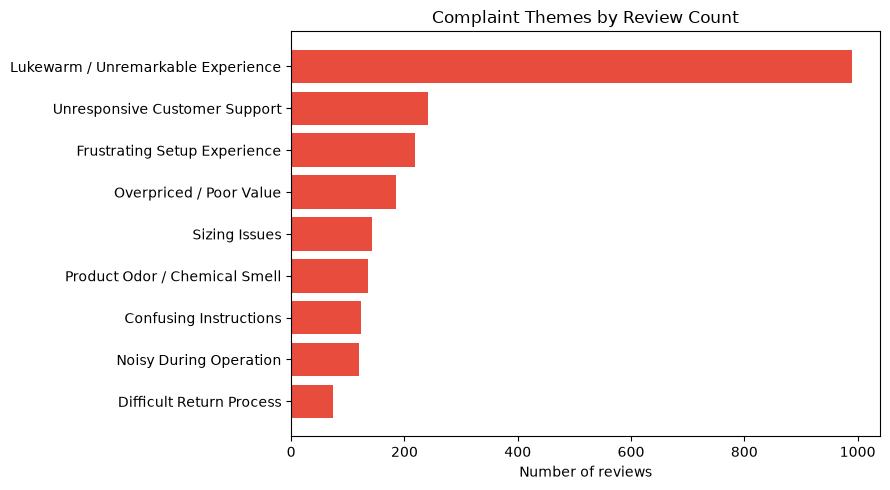

In [3]:
import matplotlib.pyplot as plt

complaints = topic_summary[topic_summary['polarity']=='complaint'].sort_values('review_count')
plt.figure(figsize=(9,5))
plt.barh(complaints['theme'], complaints['review_count'], color='#e74c3c')
plt.title('Complaint Themes by Review Count')
plt.xlabel('Number of reviews')
plt.tight_layout()
plt.show()

## Top praise themes (what customers love)

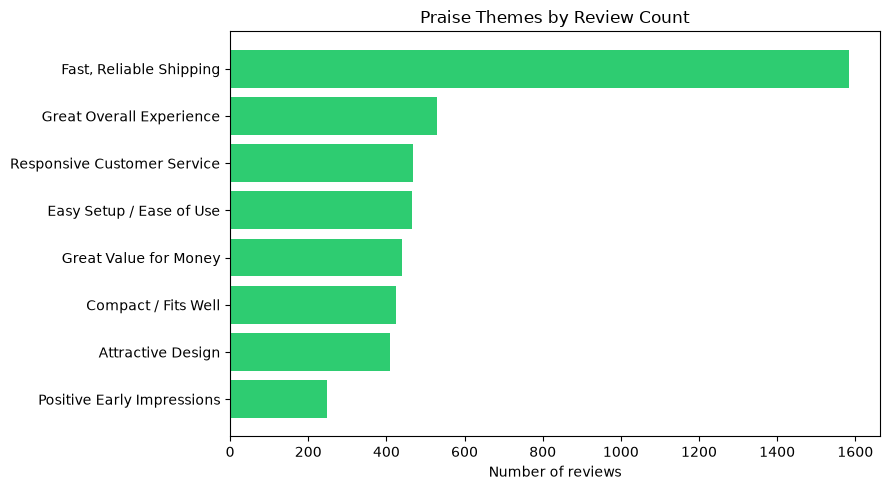

In [4]:
praise = topic_summary[topic_summary['polarity']=='praise'].sort_values('review_count')
plt.figure(figsize=(9,5))
plt.barh(praise['theme'], praise['review_count'], color='#2ecc71')
plt.title('Praise Themes by Review Count')
plt.xlabel('Number of reviews')
plt.tight_layout()
plt.show()

## A note on the "Lukewarm / Unremarkable Experience" theme
This is the largest complaint cluster, but if you inspect it, it's mostly reviews
with mild, ambiguous phrasing ("does the job", "not bad, not great") that VADER's
threshold nudged just barely into "negative". This is a real, known limitation of
lexicon-based sentiment scoring on borderline text — worth noting as a caveat in
any write-up, and a good example of why topic modeling is a useful *cross-check*
on sentiment labels, not just a downstream step.

In [5]:
df[df['theme'] == 'Lukewarm / Unremarkable Experience'][['review_text','rating','sentiment_score']].sample(5, random_state=1)

,review_text,rating,sentiment_score
5516,"Overall, Decent enough for occasional use, wou...",3,-0.3226
1559,"Honestly, It's okay, does the job but nothing ...",3,-0.1121
2421,"In short, Decent enough for occasional use, wo...",3,-0.3226
2789,"To be fair, Decent enough for occasional use, ...",3,-0.2311
4327,"Overall, It's okay, does the job but nothing s...",3,-0.3479


## Top complaint themes per product category
Which categories have which problems?

In [6]:
complaint_df = df[df['sentiment_label'] == 'negative']
cat_theme = complaint_df.groupby(['category', 'theme']).size().reset_index(name='count')
top_per_cat = cat_theme.sort_values('count', ascending=False).groupby('category').head(3)
top_per_cat.sort_values(['category','count'], ascending=[True, False])

,category,theme,count
3,Baby & Kids,Lukewarm / Unremarkable Experience,78
5,Baby & Kids,Overpriced / Poor Value,29
2,Baby & Kids,Frustrating Setup Experience,26
12,Electronics,Lukewarm / Unremarkable Experience,151
17,Electronics,Unresponsive Customer Support,96
11,Electronics,Frustrating Setup Experience,75
21,Health & Personal Care,Lukewarm / Unremarkable Experience,43
26,Health & Personal Care,Unresponsive Customer Support,16
20,Health & Personal Care,Frustrating Setup Experience,14
30,Home & Office,Lukewarm / Unremarkable Experience,87


## Complaint theme mix for a specific product
Swap the product name below to inspect any product.

In [7]:
product_name = df['product_name'].value_counts().index[0]  # change this to any product name
product_complaints = df[(df['product_name'] == product_name) & (df['sentiment_label'] == 'negative')]
print(f"Product: {product_name}")
product_complaints['theme'].value_counts()

Product: Wireless Phone Charger Stand


theme
Lukewarm / Unremarkable Experience    44
Overpriced / Poor Value                8
Frustrating Setup Experience           7
Unresponsive Customer Support          6
Sizing Issues                          6
Confusing Instructions                 3
Noisy During Operation                 3
Product Odor / Chemical Smell          2
Difficult Return Process               2
Name: count, dtype: int64